Week 3 Task: Statistical Analysis and Predictive Modeling using R

In [1]:
# Step 1: Libraries install aur load krre
packages <- c("tidyverse", "caret", "pROC", "car", "gridExtra")
new_pkgs <- packages[!(packages %in% installed.packages()[,"Package"])]
if(length(new_pkgs)) install.packages(new_pkgs, repos='https://cloud.r-project.org')

library(tidyverse)
library(caret)
library(pROC)
library(car)
library(gridExtra)

url <- "https://raw.githubusercontent.com/pplonski/datasets-for-start/master/employee_attrition/HR-Employee-Attrition-All.csv"
hr_data <- read.csv(url, stringsAsFactors = FALSE)

hr_data$Attrition <- as.factor(hr_data$Attrition)
hr_data$OverTime <- as.factor(hr_data$OverTime)
hr_data$Department <- as.factor(hr_data$Department)

cat("Libraries and Dataset successfully loaded!\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘ipred’, ‘nloptr’, ‘recipes’, ‘pbkrtest’, ‘lme4’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Loading required package: car

Libraries and Dataset successfully loaded!


In [2]:
# --- HYPOTHESIS 1: TWO-SAMPLE T-TEST (Monthly Income by Attrition) ---
cat("=== HYPOTHESIS 1: WELCH TWO-SAMPLE T-TEST ===\n")
t_res <- t.test(MonthlyIncome ~ Attrition, data = hr_data, var.equal = FALSE)
print(t_res)

# Non-parametric check (Mann-Whitney U / Wilcoxon Rank-Sum)
wilcox_res <- wilcox.test(MonthlyIncome ~ Attrition, data = hr_data)
print(wilcox_res)

# --- HYPOTHESIS 2: CHI-SQUARE TEST OF INDEPENDENCE (OverTime vs Attrition) ---
cat("\n=== HYPOTHESIS 2: CHI-SQUARE TEST OF INDEPENDENCE ===\n")
contingency_tab <- table(hr_data$OverTime, hr_data$Attrition)
chisq_res <- chisq.test(contingency_tab)
print(chisq_res)

# --- HYPOTHESIS 3: CORRELATION TEST (Tenure vs Income) ---
cat("\n=== HYPOTHESIS 3: CORRELATION TEST ===\n")
cor_res <- cor.test(hr_data$TotalWorkingYears, hr_data$MonthlyIncome)
print(cor_res)

=== HYPOTHESIS 1: WELCH TWO-SAMPLE T-TEST ===

	Welch Two Sample t-test

data:  MonthlyIncome by Attrition
t = 7.4826, df = 412.74, p-value = 4.434e-13
alternative hypothesis: true difference in means between group No and group Yes is not equal to 0
95 percent confidence interval:
 1508.244 2583.050
sample estimates:
 mean in group No mean in group Yes 
         6832.740          4787.093 


	Wilcoxon rank sum test with continuity correction

data:  MonthlyIncome by Attrition
W = 191600, p-value = 2.953e-14
alternative hypothesis: true location shift is not equal to 0


=== HYPOTHESIS 2: CHI-SQUARE TEST OF INDEPENDENCE ===

	Pearson's Chi-squared test with Yates' continuity correction

data:  contingency_tab
X-squared = 87.564, df = 1, p-value < 2.2e-16


=== HYPOTHESIS 3: CORRELATION TEST ===

	Pearson's product-moment correlation

data:  hr_data$TotalWorkingYears and hr_data$MonthlyIncome
t = 46.669, df = 1468, p-value < 2.2e-16
alternative hypothesis: true correlation is not equal t

In [3]:
# --- STEP 3: TRAIN/TEST SPLIT (80/20 Stratified Partition) ---
set.seed(42)
train_idx <- createDataPartition(hr_data$Attrition, p = 0.80, list = FALSE)
train_df <- hr_data[train_idx, ]
test_df <- hr_data[-train_idx, ]

# Fit Multivariable Logistic Regression
logit_model <- glm(Attrition ~ Age + DistanceFromHome + EnvironmentSatisfaction +
                   JobInvolvement + JobLevel + JobSatisfaction + MonthlyIncome +
                   NumCompaniesWorked + OverTime + TotalWorkingYears +
                   YearsAtCompany + YearsInCurrentRole + YearsWithCurrManager +
                   WorkLifeBalance,
                   data = train_df, family = binomial)

summary(logit_model)

# Multicollinearity Check (VIF)
cat("=== VARIANCE INFLATION FACTORS (VIF) ===\n")
print(vif(logit_model))

# Odds Ratios [exp(beta)] and 95% Confidence Intervals
cat("\n=== LOGISTIC REGRESSION ODDS RATIOS ===\n")
odds_ratios <- exp(cbind(OR = coef(logit_model), confint.default(logit_model)))
print(round(odds_ratios, 3))


Call:
glm(formula = Attrition ~ Age + DistanceFromHome + EnvironmentSatisfaction + 
    JobInvolvement + JobLevel + JobSatisfaction + MonthlyIncome + 
    NumCompaniesWorked + OverTime + TotalWorkingYears + YearsAtCompany + 
    YearsInCurrentRole + YearsWithCurrManager + WorkLifeBalance, 
    family = binomial, data = train_df)

Coefficients:
                          Estimate Std. Error z value Pr(>|z|)    
(Intercept)              3.613e+00  7.115e-01   5.078 3.81e-07 ***
Age                     -4.302e-02  1.412e-02  -3.047  0.00231 ** 
DistanceFromHome         2.860e-02  1.075e-02   2.660  0.00782 ** 
EnvironmentSatisfaction -3.807e-01  8.241e-02  -4.619 3.86e-06 ***
JobInvolvement          -5.410e-01  1.200e-01  -4.509 6.50e-06 ***
JobLevel                -2.578e-02  2.811e-01  -0.092  0.92694    
JobSatisfaction         -3.622e-01  8.044e-02  -4.502 6.73e-06 ***
MonthlyIncome           -4.508e-05  6.749e-05  -0.668  0.50418    
NumCompaniesWorked       1.538e-01  3.767e-02   4.

=== VARIANCE INFLATION FACTORS (VIF) ===
                    Age        DistanceFromHome EnvironmentSatisfaction 
               1.772129                1.024267                1.036249 
         JobInvolvement                JobLevel         JobSatisfaction 
               1.024316                7.859429                1.041184 
          MonthlyIncome      NumCompaniesWorked                OverTime 
               7.358292                1.272063                1.079096 
      TotalWorkingYears          YearsAtCompany      YearsInCurrentRole 
               4.161068                4.655062                2.459499 
   YearsWithCurrManager         WorkLifeBalance 
               2.485538                1.011959 

=== LOGISTIC REGRESSION ODDS RATIOS ===
                            OR 2.5 %  97.5 %
(Intercept)             37.078 9.194 149.532
Age                      0.958 0.932   0.985
DistanceFromHome         1.029 1.008   1.051
EnvironmentSatisfaction  0.683 0.581   0.803
JobInvolvem

Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  243  35
       Yes   3  12
                                          
               Accuracy : 0.8703          
                 95% CI : (0.8264, 0.9066)
    No Information Rate : 0.8396          
    P-Value [Acc > NIR] : 0.08532         
                                          
                  Kappa : 0.3355          
                                          
 Mcnemar's Test P-Value : 4.934e-07       
                                          
            Sensitivity : 0.25532         
            Specificity : 0.98780         
         Pos Pred Value : 0.80000         
         Neg Pred Value : 0.87410         
             Prevalence : 0.16041         
         Detection Rate : 0.04096         
   Detection Prevalence : 0.05119         
      Balanced Accuracy : 0.62156         
                                          
       'Positive' Class : Yes             
                              

Setting levels: control = No, case = Yes

Setting direction: controls < cases




Receiver Operating Characteristic (ROC) AUC: 0.8172 


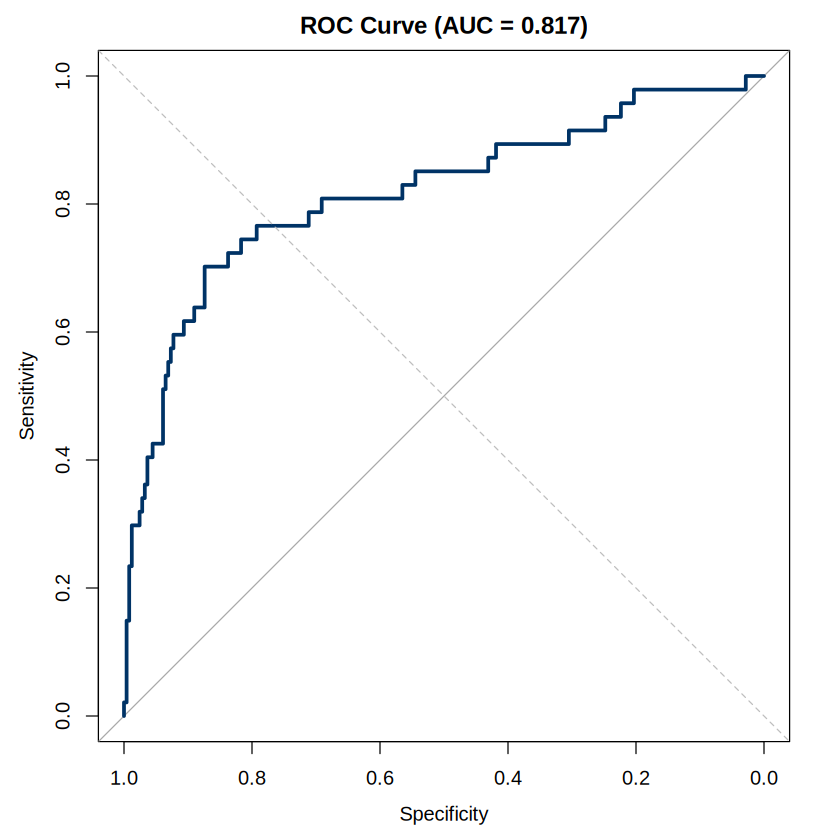

In [4]:
# Test set par predictions
test_df$pred_prob <- predict(logit_model, newdata = test_df, type = "response")
test_df$pred_class <- as.factor(ifelse(test_df$pred_prob > 0.50, "Yes", "No"))

# Confusion Matrix
cm <- confusionMatrix(test_df$pred_class, test_df$Attrition, positive = "Yes")
print(cm)

# ROC Curve & Area Under the Curve (AUC)
roc_obj <- roc(test_df$Attrition, test_df$pred_prob)
auc_val <- auc(roc_obj)
cat("\nReceiver Operating Characteristic (ROC) AUC:", round(auc_val, 4), "\n")

# Plot ROC Curve
plot(roc_obj, col = "#003366", lwd = 3, main = paste0("ROC Curve (AUC = ", round(auc_val, 3), ")"))
abline(a = 0, b = 1, lty = 2, col = "gray")


Call:
lm(formula = MonthlyIncome ~ TotalWorkingYears + JobLevel + Age + 
    YearsAtCompany, data = hr_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-5371.1  -933.8    91.4   771.7  3884.4 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -1545.221    183.228  -8.433  < 2e-16 ***
TotalWorkingYears    60.947     10.181   5.987 2.69e-09 ***
JobLevel           3793.199     55.029  68.931  < 2e-16 ***
Age                  -9.765      5.766  -1.693   0.0906 .  
YearsAtCompany      -15.368      8.121  -1.892   0.0586 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1448 on 1465 degrees of freedom
Multiple R-squared:  0.9057,	Adjusted R-squared:  0.9054 
F-statistic:  3516 on 4 and 1465 DF,  p-value: < 2.2e-16


All models, hypothesis tests, and diagnostic evaluations complete!


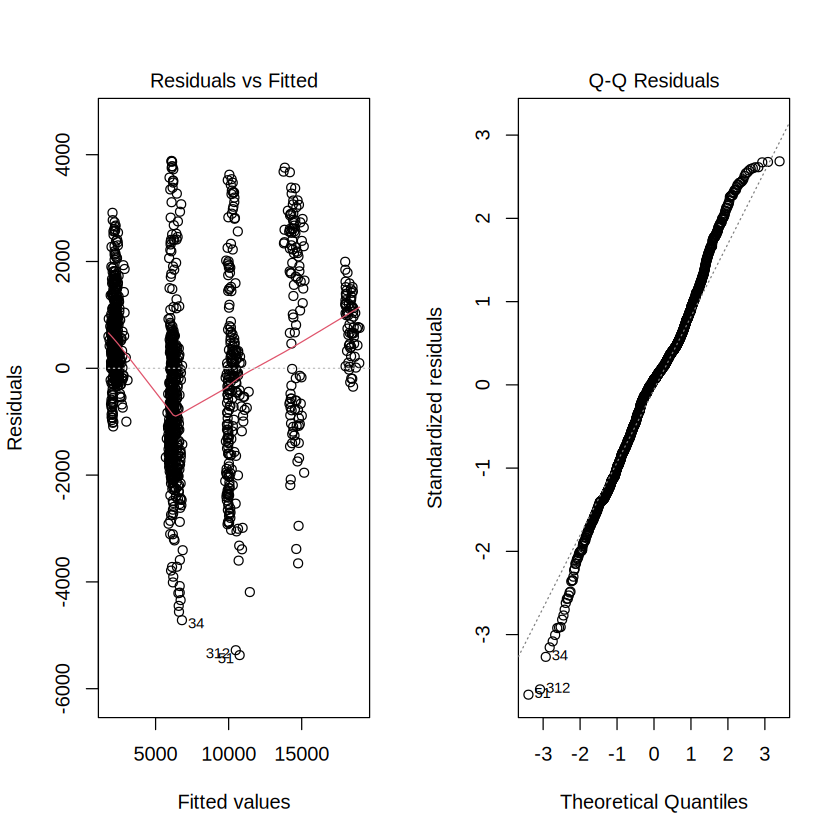

In [5]:
# Linear Regression for Continuous Outcome (Monthly Income)
lm_model <- lm(MonthlyIncome ~ TotalWorkingYears + JobLevel + Age + YearsAtCompany, data = hr_data)
summary(lm_model)

# Residual Diagnostic Plots (Residuals vs Fitted & Normal Q-Q)
par(mfrow = c(1, 2))
plot(lm_model, which = c(1, 2))
par(mfrow = c(1, 1))

cat("All models, hypothesis tests, and diagnostic evaluations complete!\n")